# Ridge Analysis

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path
import importlib

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler



# fix file path
sys.path.append(str(Path("..").resolve()))

from Implementations import prepare_data
importlib.reload(prepare_data)

from Implementations.prepare_data import prepare_data



### Fetching data

In [2]:
df = pd.read_csv("../Data_Processed/player_core_features.csv")

data = prepare_data(df, test_size=0.2, seed=6114)
print(data["summary"])

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["ylog_train"].ravel()
y_test  = data["ylog_test"].ravel()

feature_cols = data["feature_cols"]
groups_full = data["groups_full"]


{'n_rows_total': 278558, 'n_rows_used': 275230, 'n_features': 24, 'test_size': 0.2, 'seed': 6114, 'numeric_only': True, 'drop_na': True, 'standardize': True, 'player_overlap_train_test': 0}


### Ridge Baseline

In [4]:
lam = 1.0
ridge = Ridge(alpha=lam)  # Baseline, arbitrary lambda
ridge.fit(X_train, y_train)

pred_test = ridge.predict(X_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_test)

print(f"Ridge(lambda={lam}) | RMSE(log)={rmse:.4f} | R2(log)={r2:.4f}")


Ridge(lambda=1.0) | RMSE(log)=1.0631 | R2(log)=0.5060


### K-fold (group) cross validation

/Users/adnerolstad/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.26333e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/adnerolstad/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.79517e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Best lambda (GroupKFold on TRAIN): 1.778e+02 | CV RMSE(log)=1.0792


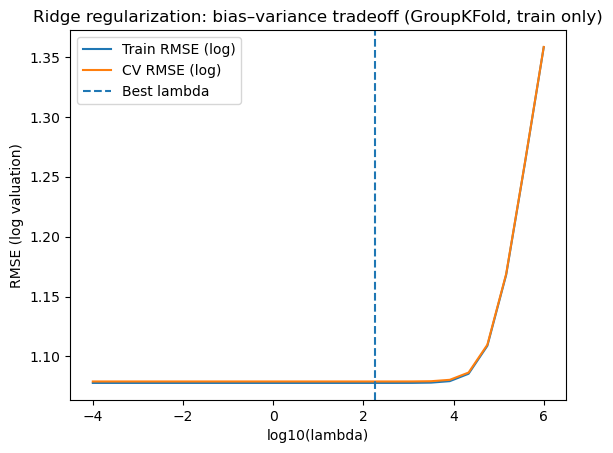

In [5]:
X_tr = data["X_train"]
y_tr = data["ylog_train"].ravel()
groups_tr = data["groups_train"]

lambdas = np.logspace(-4, 6, 25)  # test 25 different lambdas, log-spaced
gkf = GroupKFold(n_splits=5)

train_rmse = []
val_rmse = []

for lam in lambdas:
    rmse_tr_folds = []
    rmse_va_folds = []

    for tr_idx, va_idx in gkf.split(X_tr, y_tr, groups=groups_tr):
        model = Ridge(alpha=lam)
        model.fit(X_tr[tr_idx], y_tr[tr_idx])
        
        pred_tr = model.predict(X_tr[tr_idx])
        pred_va = model.predict(X_tr[va_idx])

        rmse_tr_folds.append(np.sqrt(mean_squared_error(y_tr[tr_idx], pred_tr)))
        rmse_va_folds.append(np.sqrt(mean_squared_error(y_tr[va_idx], pred_va)))

    train_rmse.append(np.mean(rmse_tr_folds))
    val_rmse.append(np.mean(rmse_va_folds))

best_i = int(np.argmin(val_rmse))
best_lambda = lambdas[best_i]

print(f"Best lambda (GroupKFold on TRAIN): {best_lambda:.3e} | CV RMSE(log)={val_rmse[best_i]:.4f}")

plt.figure()
plt.plot(np.log10(lambdas), train_rmse, label="Train RMSE (log)")
plt.plot(np.log10(lambdas), val_rmse, label="CV RMSE (log)")
plt.axvline(np.log10(best_lambda), linestyle="--", label="Best lambda")
plt.xlabel("log10(lambda)")
plt.ylabel("RMSE (log valuation)")
plt.title("Ridge regularization: bias–variance tradeoff (GroupKFold, train only)")
plt.legend()
plt.show()


### Ridge model, optimal lambda

In [6]:
ridge_best = Ridge(alpha=best_lambda)
ridge_best.fit(data["X_train"], data["ylog_train"].ravel())

pred_test = ridge_best.predict(data["X_test"])
mse_test = mean_squared_error(data["ylog_test"].ravel(), pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(data["ylog_test"].ravel(), pred_test)

print(f"Ridge(best alpha={best_lambda:.2e}) | RMSE(log)={rmse_test:.4f} | R2(log)={r2_test:.4f}")


Ridge(best alpha=1.78e+02) | RMSE(log)=1.0631 | R2(log)=0.5059


### Plotting results

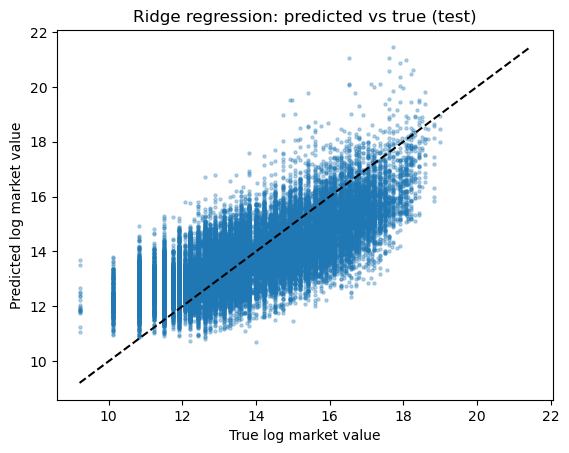

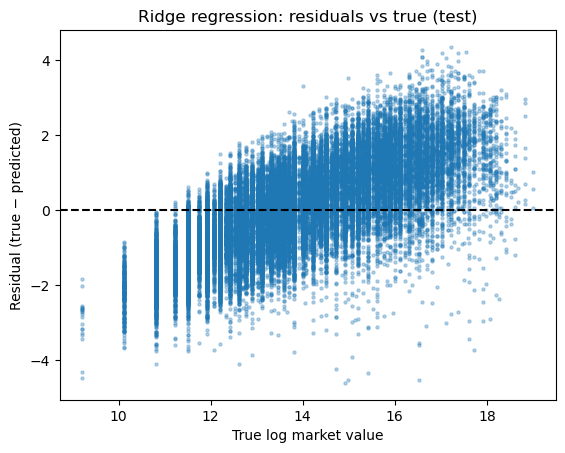

In [7]:
pred = ridge_best.predict(X_test)
residuals = y_test - pred

# Predicted vs true
plt.figure()
plt.scatter(y_test, pred, s=5, alpha=0.3)
mn = min(y_test.min(), pred.min())
mx = max(y_test.max(), pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--", color="black")
plt.xlabel("True log market value")
plt.ylabel("Predicted log market value")
plt.title("Ridge regression: predicted vs true (test)")
plt.show()

# Residuals vs true
plt.figure()
plt.scatter(y_test, residuals, s=5, alpha=0.3)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("True log market value")
plt.ylabel("Residual (true − predicted)")
plt.title("Ridge regression: residuals vs true (test)")
plt.show()

### Plotting/Presenting the Coefficients

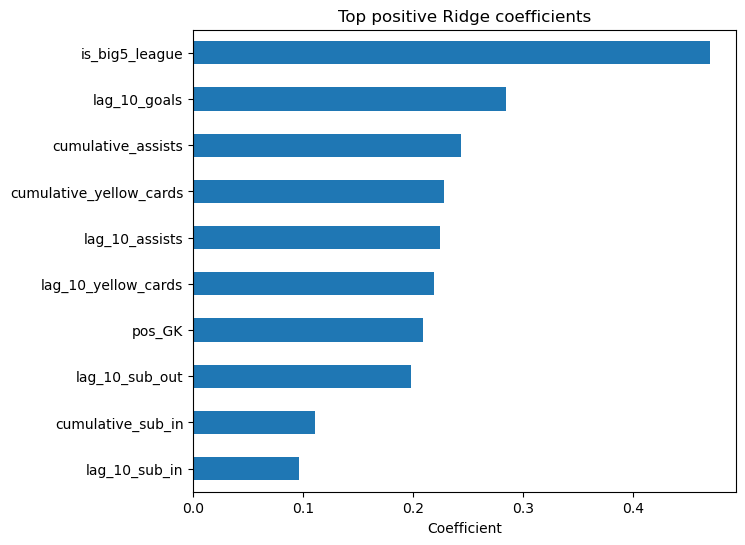

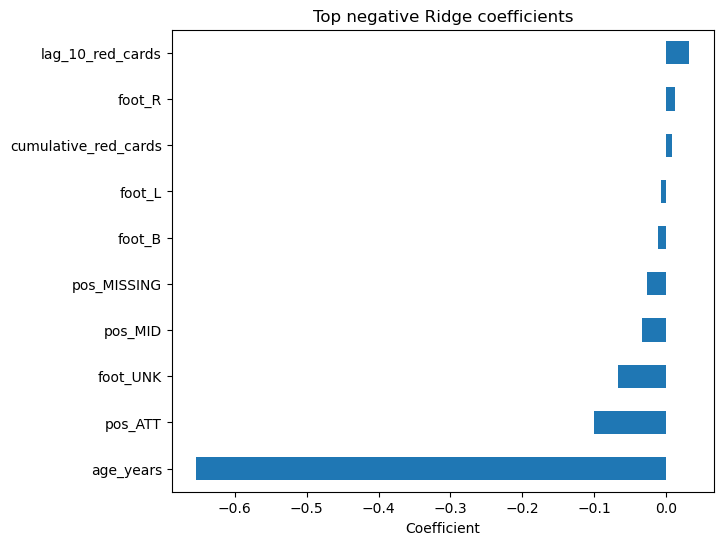

In [8]:
coef = pd.Series(ridge_best.coef_, index=feature_cols).sort_values()

plt.figure(figsize=(7, 6))
coef.tail(10).plot(kind="barh")
plt.title("Top positive Ridge coefficients")
plt.xlabel("Coefficient")
plt.show()

plt.figure(figsize=(7, 6))
coef.head(10).plot(kind="barh")
plt.title("Top negative Ridge coefficients")
plt.xlabel("Coefficient")
plt.show()

